# Scientific Machine Learning HW 1: Support Vector Machines and Phase Transition of Ising Model

In [23]:
import numpy as np

try:
    from sklearnex import patch_sklearn
    patch_sklearn()
except:
    print("Intel® Extension for Scikit-learn* not installed.")

from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
import pickle

import sklearn
sklearn.set_config(enable_metadata_routing = True)

from sklearn.linear_model import LogisticRegressionCV
from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


## Prepare Data

In [24]:
# The data consists of 16 * 10000 samples taken in T = {0.25, 0.5, ..., 4.}.
# Each sample consists of spins in a 40 * 40 lattice.
temps = np.repeat(np.linspace(0.25, 4., 16), 10000)
T_c = 2 / np.log(1 + np.sqrt(2))
# The first 9 * 10000 samples are ordered (label 1).
# The remaining 7 * 10000 samples are disordered (label 0).
data_file_name = "Ising2DFM_reSample_L40_T=All.pkl"
label_file_name = "Ising2DFM_reSample_L40_T=All_labels.pkl"

with open(data_file_name, "rb") as pickle_file:
    data = pickle.load(pickle_file)
data = np.ascontiguousarray(np.unpackbits(data).reshape(-1, 1600), dtype = np.float64)
data[np.where(data==0)] = -1

# Label is 1 for ordered states and 0 for disordered states
with open(label_file_name, "rb") as pickle_file:
    labels = np.ascontiguousarray(pickle.load(pickle_file), dtype = np.float64)

print("Data shape:", data.shape)
print("Labels:", np.unique(labels))

Data shape: (160000, 1600)
Labels: [0. 1.]


In [25]:
# 75% train, 25% test
data_train, data_test, labels_train, labels_test, temps_train, temps_test = train_test_split(data, labels, temps, stratify = temps)

In [26]:
scores = ["accuracy", "precision", "recall", "f1"]
scorers = [make_scorer(accuracy_score),
           make_scorer(precision_score, zero_division = np.nan),
           make_scorer(recall_score, zero_division = np.nan),
           make_scorer(f1_score, zero_division = np.nan)]

In [27]:
def evaluate_models(models):
    model_scores = np.zeros(len(scorers))
    model_scores_temps = np.zeros((len(scorers), 16))

    for i in tqdm(range(len(models))):
        print("Metric: {}".format(scores[i]))
        model_scores[i] = models[i].score(data_test, labels_test)
        print("Overall {}: {:.4f}".format(scores[i], model_scores[i]))
        for j in range(16):
            temp = 0.25 * (j + 1)
            model_scores_temps[i, j] = models[i].score(data_test[temps_test == temp], labels_test[temps_test == temp])
        
        if scores[i] == "accuracy":
            print("Best {}: {:.4f} at T = {}".format(scores[i], np.nanmax(model_scores_temps[i]),
                                                     0.25 * (np.nanargmax(model_scores_temps[i]) + 1)))
            print("Worst {}: {:.4f} at T = {}".format(scores[i], np.nanmin(model_scores_temps[i]),
                                                      0.25 * (np.nanargmin(model_scores_temps[i]) + 1)))
        else:
            # Use only positive (ordered) samples for recall, precision, and F1
            print("Best {}: {:.4f} at T = {}".format(scores[i], np.nanmax(model_scores_temps[i, :9]),
                                                     0.25 * (np.nanargmax(model_scores_temps[i, :9]) + 1)))
            print("Worst {}: {:.4f} at T = {}".format(scores[i], np.nanmin(model_scores_temps[i, :9]),
                                                      0.25 * (np.nanargmin(model_scores_temps[i, :9]) + 1)))
        print()
    return model_scores, model_scores_temps

## Logistic Regression

In [28]:
lr_models = [LogisticRegressionCV(l1_ratios = (0,), scoring = scorer, max_iter = 1000,
                                  cv = StratifiedKFold(n_splits = 5, shuffle = True), n_jobs = -2,
                                  use_legacy_attributes = False)
             for scorer in scorers]

In [29]:
# Takes about 1 minute per model on my laptop
for lr_model in tqdm(lr_models):
    lr_model.fit(data_train, labels_train)

  0%|          | 0/4 [00:00<?, ?it/s]

In [30]:
lr_scores, lr_scores_temps = evaluate_models(lr_models)

  0%|          | 0/4 [00:00<?, ?it/s]

Metric: accuracy
Overall accuracy: 0.6523
Best accuracy: 1.0000 at T = 0.25
Worst accuracy: 0.2168 at T = 2.5

Metric: precision
Overall precision: 0.6213
Best precision: 1.0000 at T = 0.25
Worst precision: 1.0000 at T = 0.25

Metric: recall
Overall recall: 0.9974
Best recall: 1.0000 at T = 0.25
Worst recall: 0.9788 at T = 2.25

Metric: f1
Overall f1: 0.7597
Best f1: 1.0000 at T = 0.25
Worst f1: 0.9259 at T = 2.25



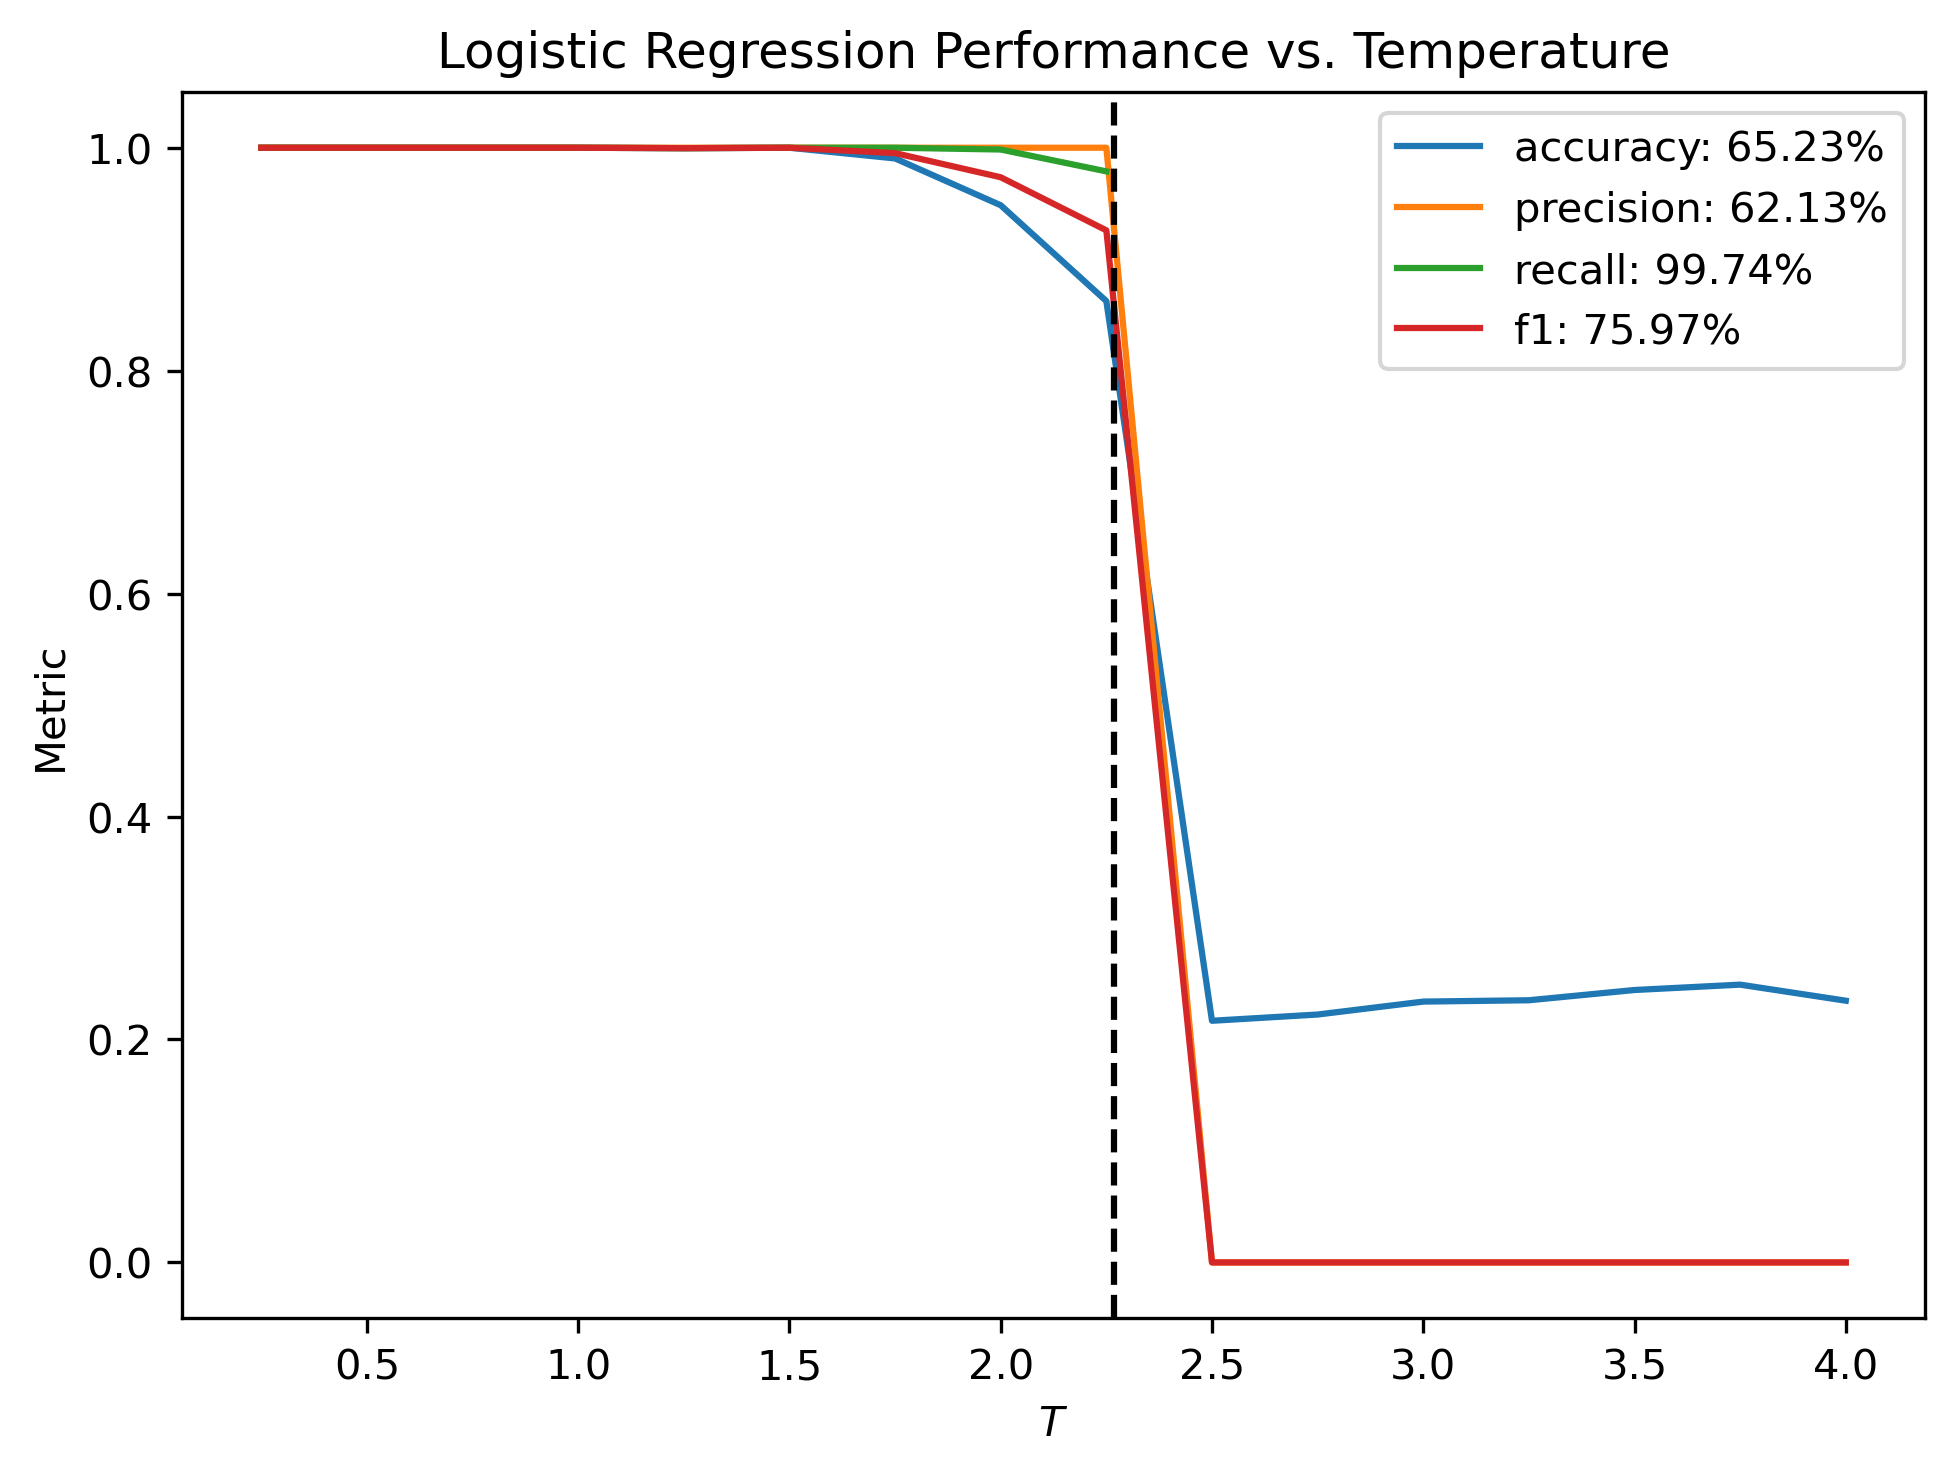

In [31]:
plt.figure(dpi = 300, layout = "constrained")
for i in range(len(scorers)):
    plt.plot(np.linspace(0.25, 4., 16), lr_scores_temps[i], label = "{}: {:.2%}".format(scores[i], lr_scores[i]))
plt.axvline(T_c, color = "k", linestyle = "--")
plt.xlabel(r"$T$")
plt.ylabel("Metric")
plt.title("Logistic Regression Performance vs. Temperature")
plt.legend()
plt.savefig("logistic.pdf")

## SVM

In [32]:
linear_svm_pipe = make_pipeline(StandardScaler(), LinearSVC(class_weight = "balanced"))
svm_pipe = make_pipeline(StandardScaler(), SVC(cache_size = 2000, class_weight = "balanced"))

# GridSearchCV breaks if we use n_jobs, for some reason.
linear_svm_models = [GridSearchCV(estimator = linear_svm_pipe, param_grid = {"linearsvc__C": np.logspace(-2, 2, 5)}, scoring = scorer,
                                  cv = StratifiedKFold(n_splits = 4, shuffle = True), verbose = 1)
                     for scorer in scorers]

svm_models = [GridSearchCV(estimator = svm_pipe, param_grid = {"svc__C": np.logspace(-2, 2, 5)}, scoring = scorer,
                           cv = StratifiedKFold(n_splits = 4, shuffle = True), verbose = 1)
              for scorer in scorers]

In [ ]:
# Takes about 35 minutes overall
for linear_svm_model in tqdm(linear_svm_models):
    linear_svm_model.fit(data_train, labels_train)

  0%|          | 0/4 [00:00<?, ?it/s]

Fitting 4 folds for each of 5 candidates, totalling 20 fits
Fitting 4 folds for each of 5 candidates, totalling 20 fits
Fitting 4 folds for each of 5 candidates, totalling 20 fits
Fitting 4 folds for each of 5 candidates, totalling 20 fits


In [ ]:
# Takes about 50 minutes overall
for svm_model in tqdm(svm_models):
    svm_model.fit(data_train, labels_train)

  0%|          | 0/4 [00:00<?, ?it/s]

Fitting 4 folds for each of 5 candidates, totalling 20 fits
Fitting 4 folds for each of 5 candidates, totalling 20 fits
Fitting 4 folds for each of 5 candidates, totalling 20 fits
Fitting 4 folds for each of 5 candidates, totalling 20 fits


In [35]:
linear_svm_scores, linear_svm_scores_temps = evaluate_models(linear_svm_models)

  0%|          | 0/4 [00:00<?, ?it/s]

Metric: accuracy
Overall accuracy: 0.6501
Best accuracy: 1.0000 at T = 0.25
Worst accuracy: 0.4628 at T = 3.25

Metric: precision
Overall precision: 0.6584
Best precision: 1.0000 at T = 0.25
Worst precision: 1.0000 at T = 0.25

Metric: recall
Overall recall: 0.7855
Best recall: 1.0000 at T = 0.25
Worst recall: 0.5364 at T = 2.25

Metric: f1
Overall f1: 0.7164
Best f1: 1.0000 at T = 0.25
Worst f1: 0.6983 at T = 2.25



In [36]:
svm_scores, svm_scores_temps = evaluate_models(svm_models)

  0%|          | 0/4 [00:00<?, ?it/s]

Metric: accuracy
Overall accuracy: 0.9977
Best accuracy: 1.0000 at T = 0.25
Worst accuracy: 0.9668 at T = 2.25

Metric: precision
Overall precision: 1.0000
Best precision: 1.0000 at T = 0.25
Worst precision: 1.0000 at T = 0.25

Metric: recall
Overall recall: 0.9963
Best recall: 1.0000 at T = 0.25
Worst recall: 0.9668 at T = 2.25

Metric: f1
Overall f1: 0.9980
Best f1: 1.0000 at T = 0.25
Worst f1: 0.9831 at T = 2.25



  0%|          | 0/4 [00:00<?, ?it/s]

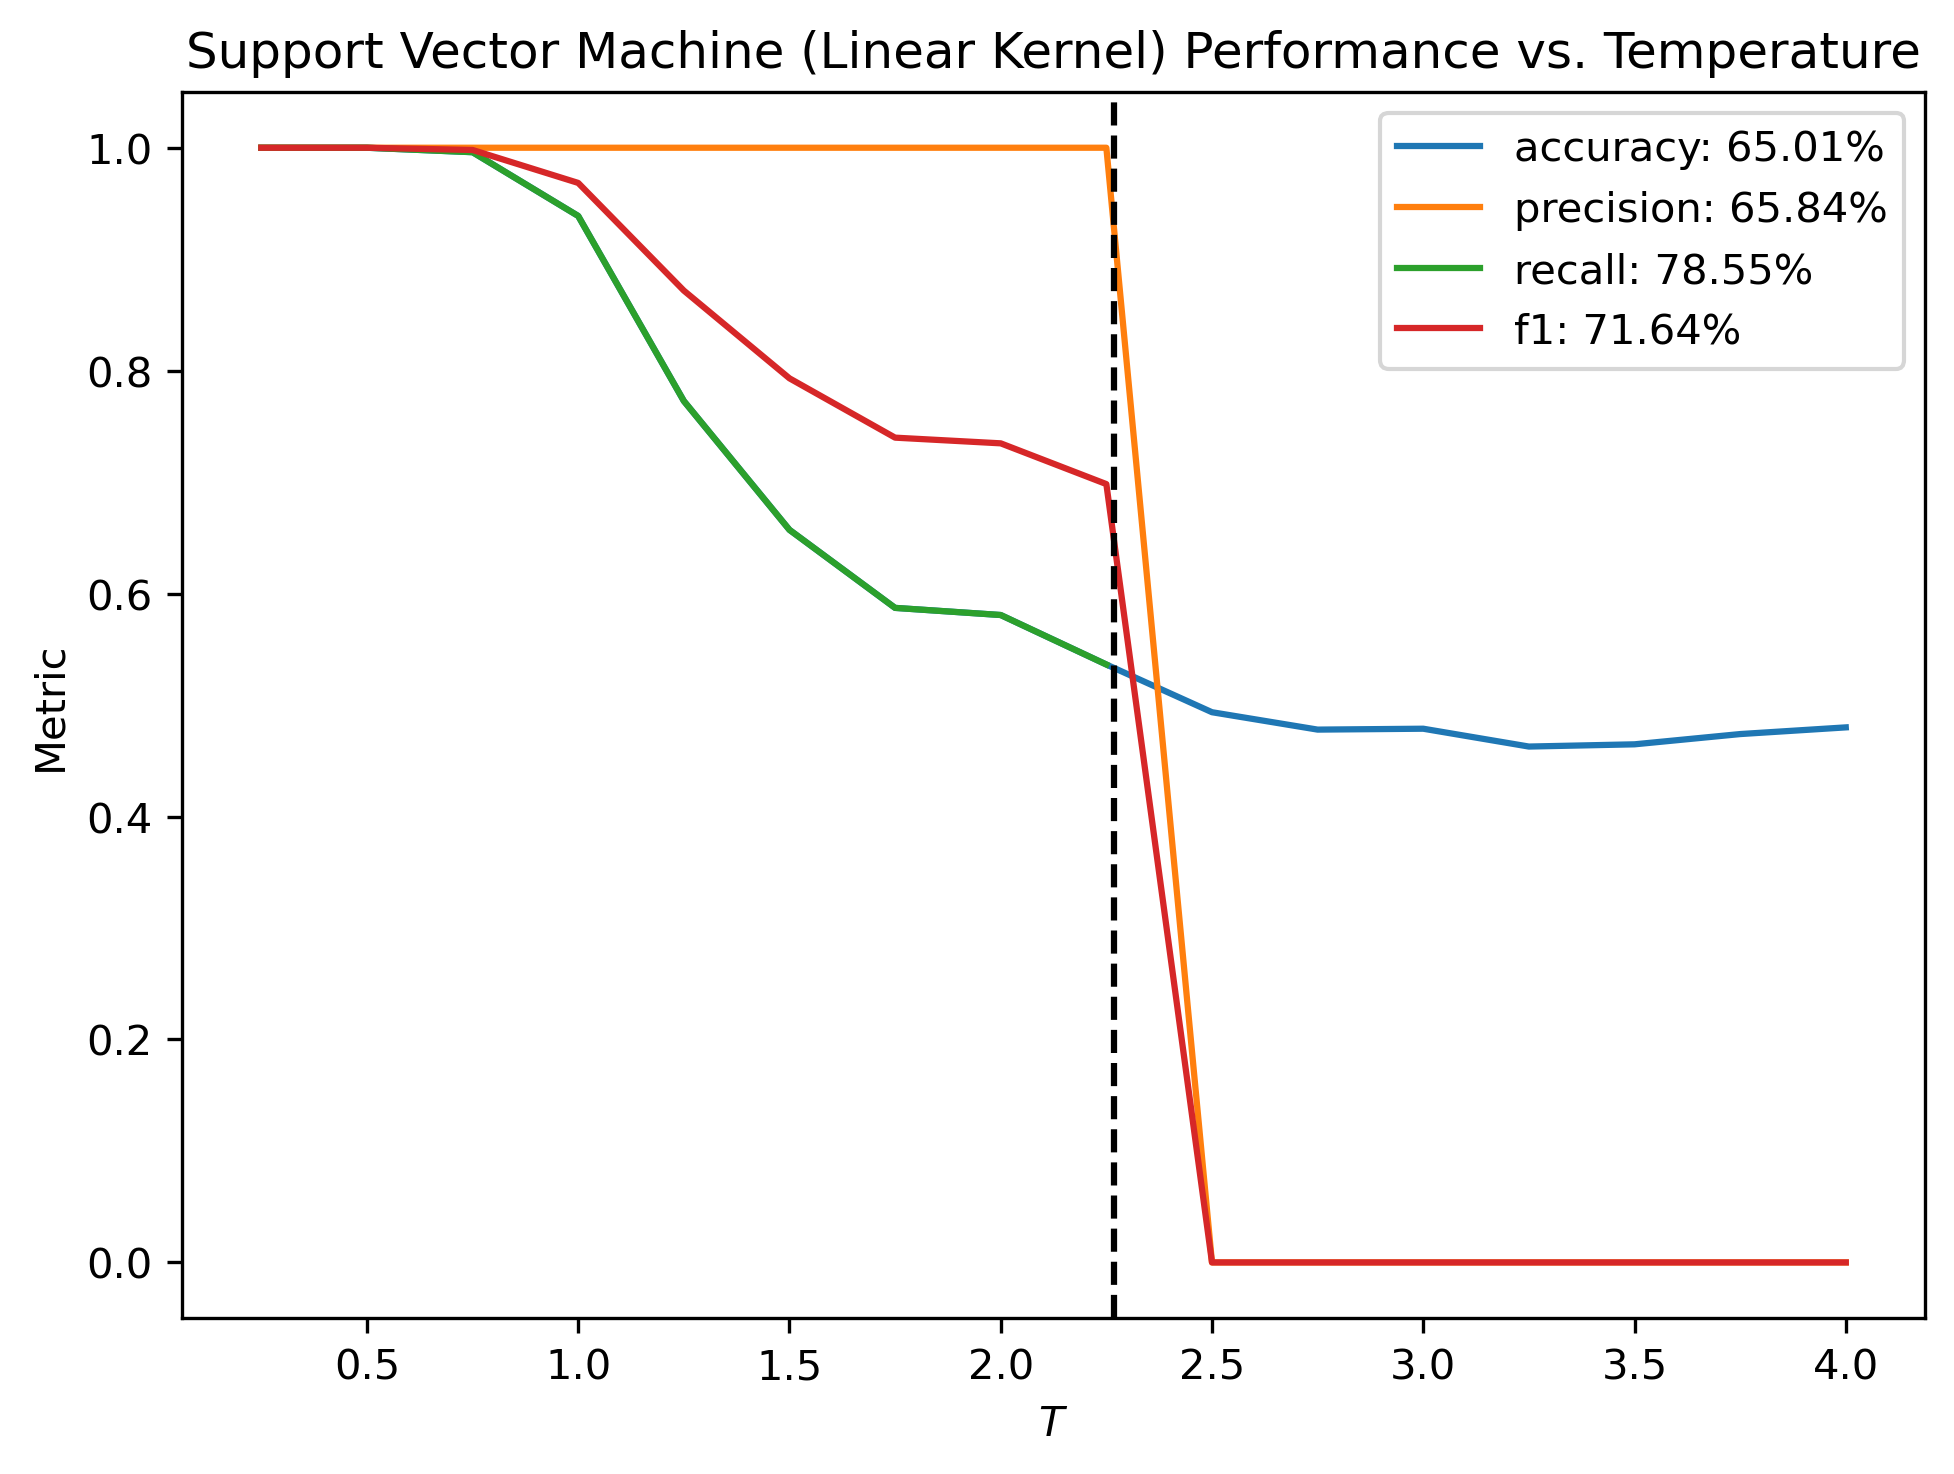

In [37]:
plt.figure(dpi = 300, layout = "constrained")
for i in tqdm(range(len(scorers))):
    plt.plot(np.linspace(0.25, 4., 16), linear_svm_scores_temps[i], label = "{}: {:.2%}".format(scores[i], linear_svm_scores[i]))
plt.axvline(T_c, color = "k", linestyle = "--")
plt.xlabel(r"$T$")
plt.ylabel("Metric")
plt.title("Support Vector Machine (Linear Kernel) Performance vs. Temperature")
plt.legend()
plt.savefig("linear_svm.pdf")

  0%|          | 0/4 [00:00<?, ?it/s]

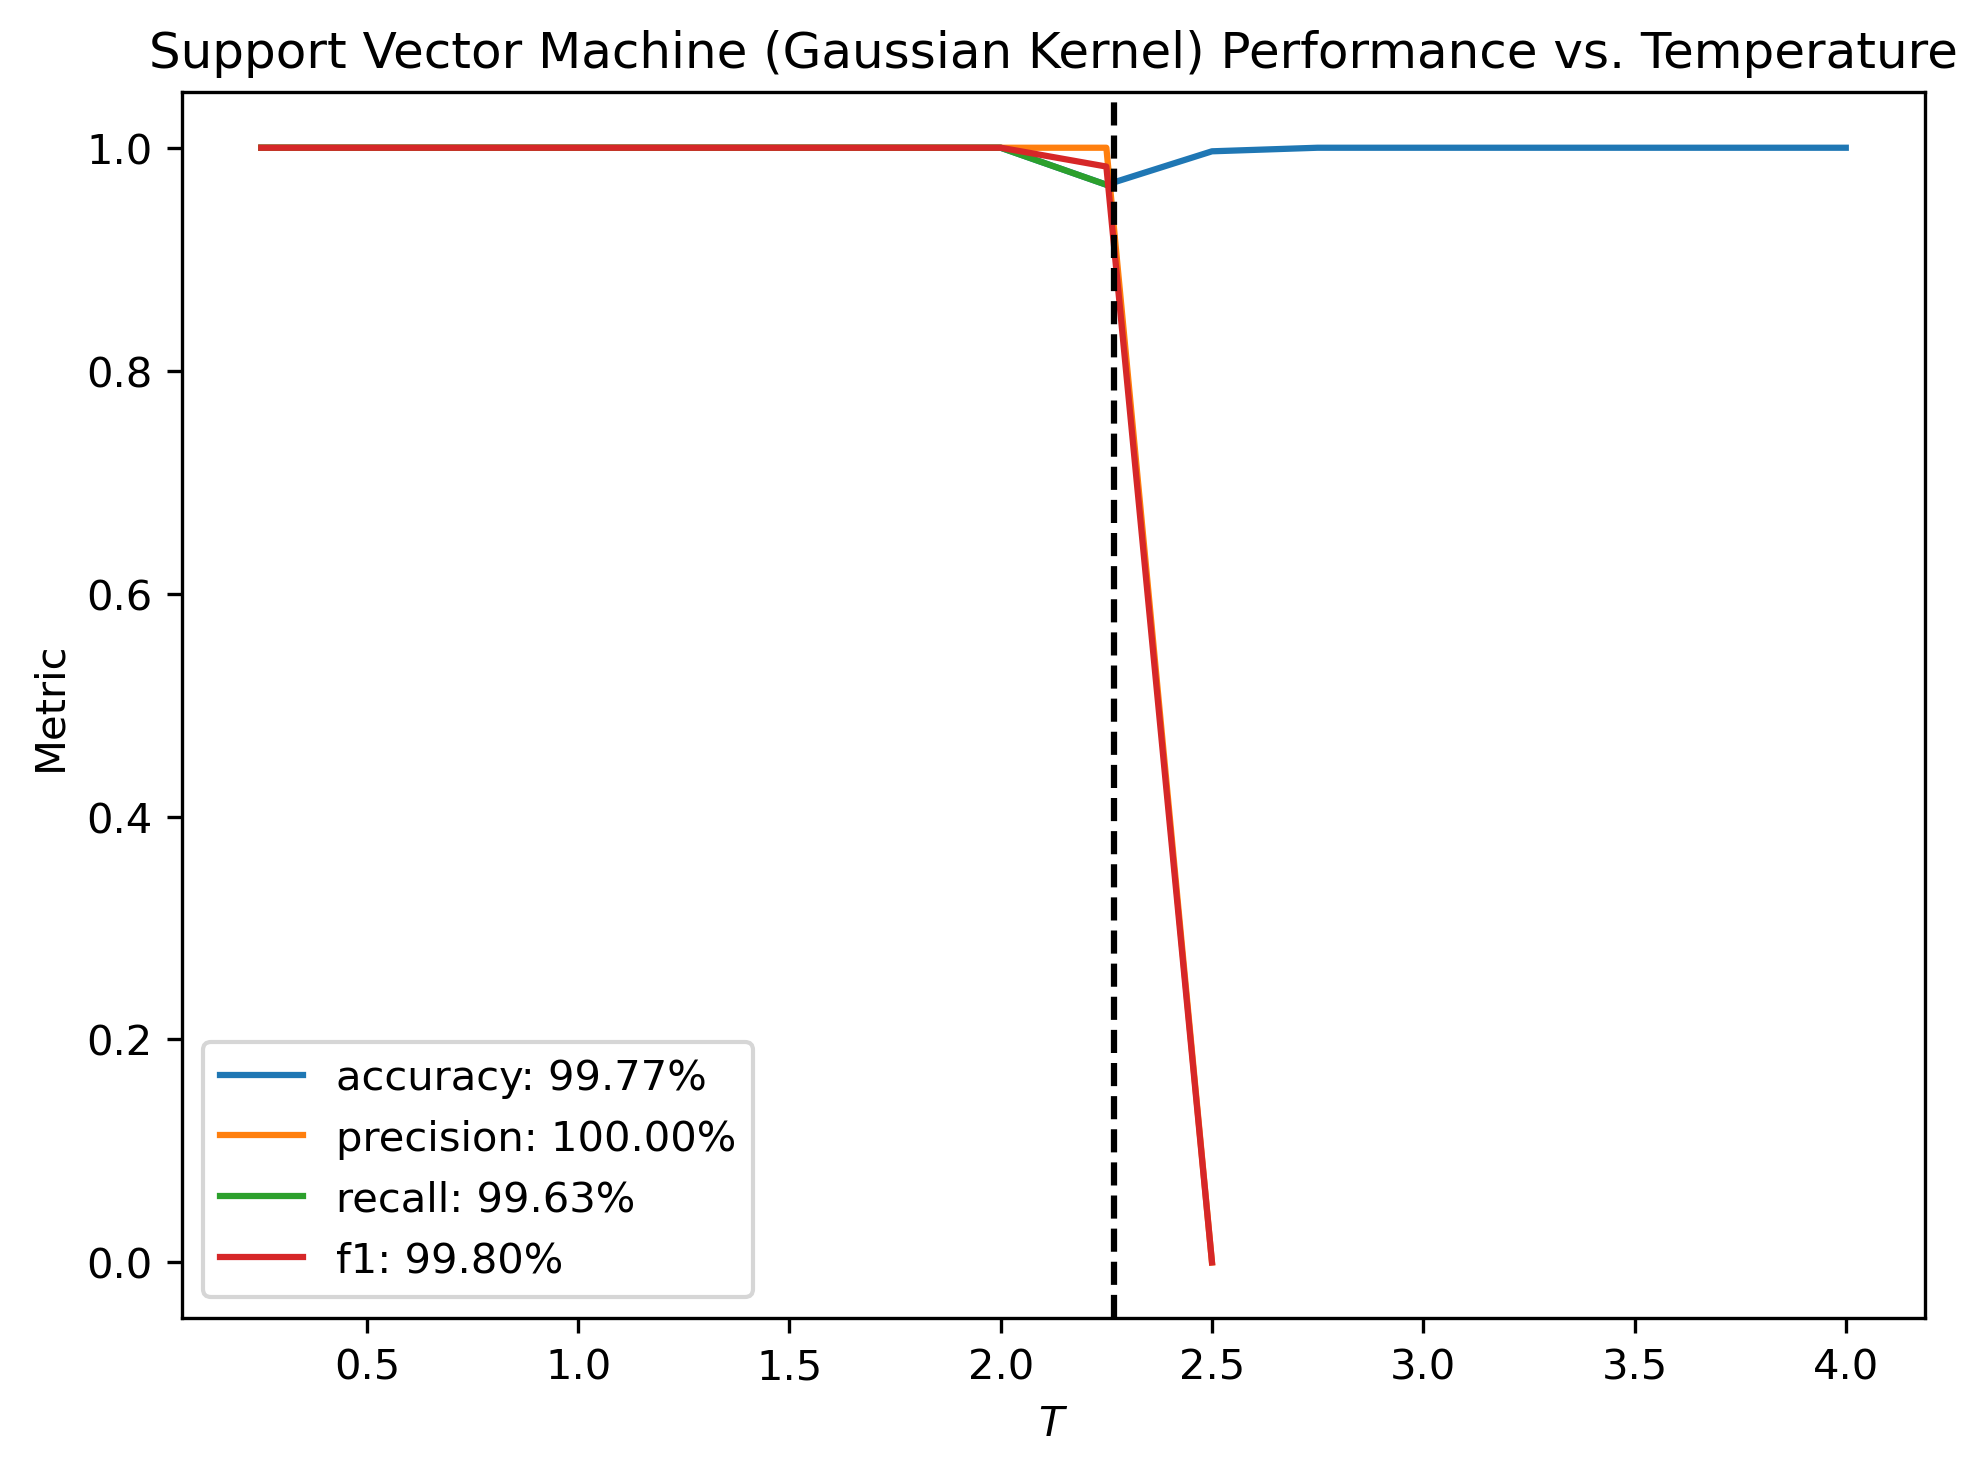

In [38]:
plt.figure(dpi = 300, layout = "constrained")
for i in tqdm(range(len(scorers))):
    plt.plot(np.linspace(0.25, 4., 16), svm_scores_temps[i], label = "{}: {:.2%}".format(scores[i], svm_scores[i]))
plt.axvline(T_c, color = "k", linestyle = "--")
plt.xlabel(r"$T$")
plt.ylabel("Metric")
plt.title("Support Vector Machine (Gaussian Kernel) Performance vs. Temperature")
plt.legend()
plt.savefig("svm.pdf")

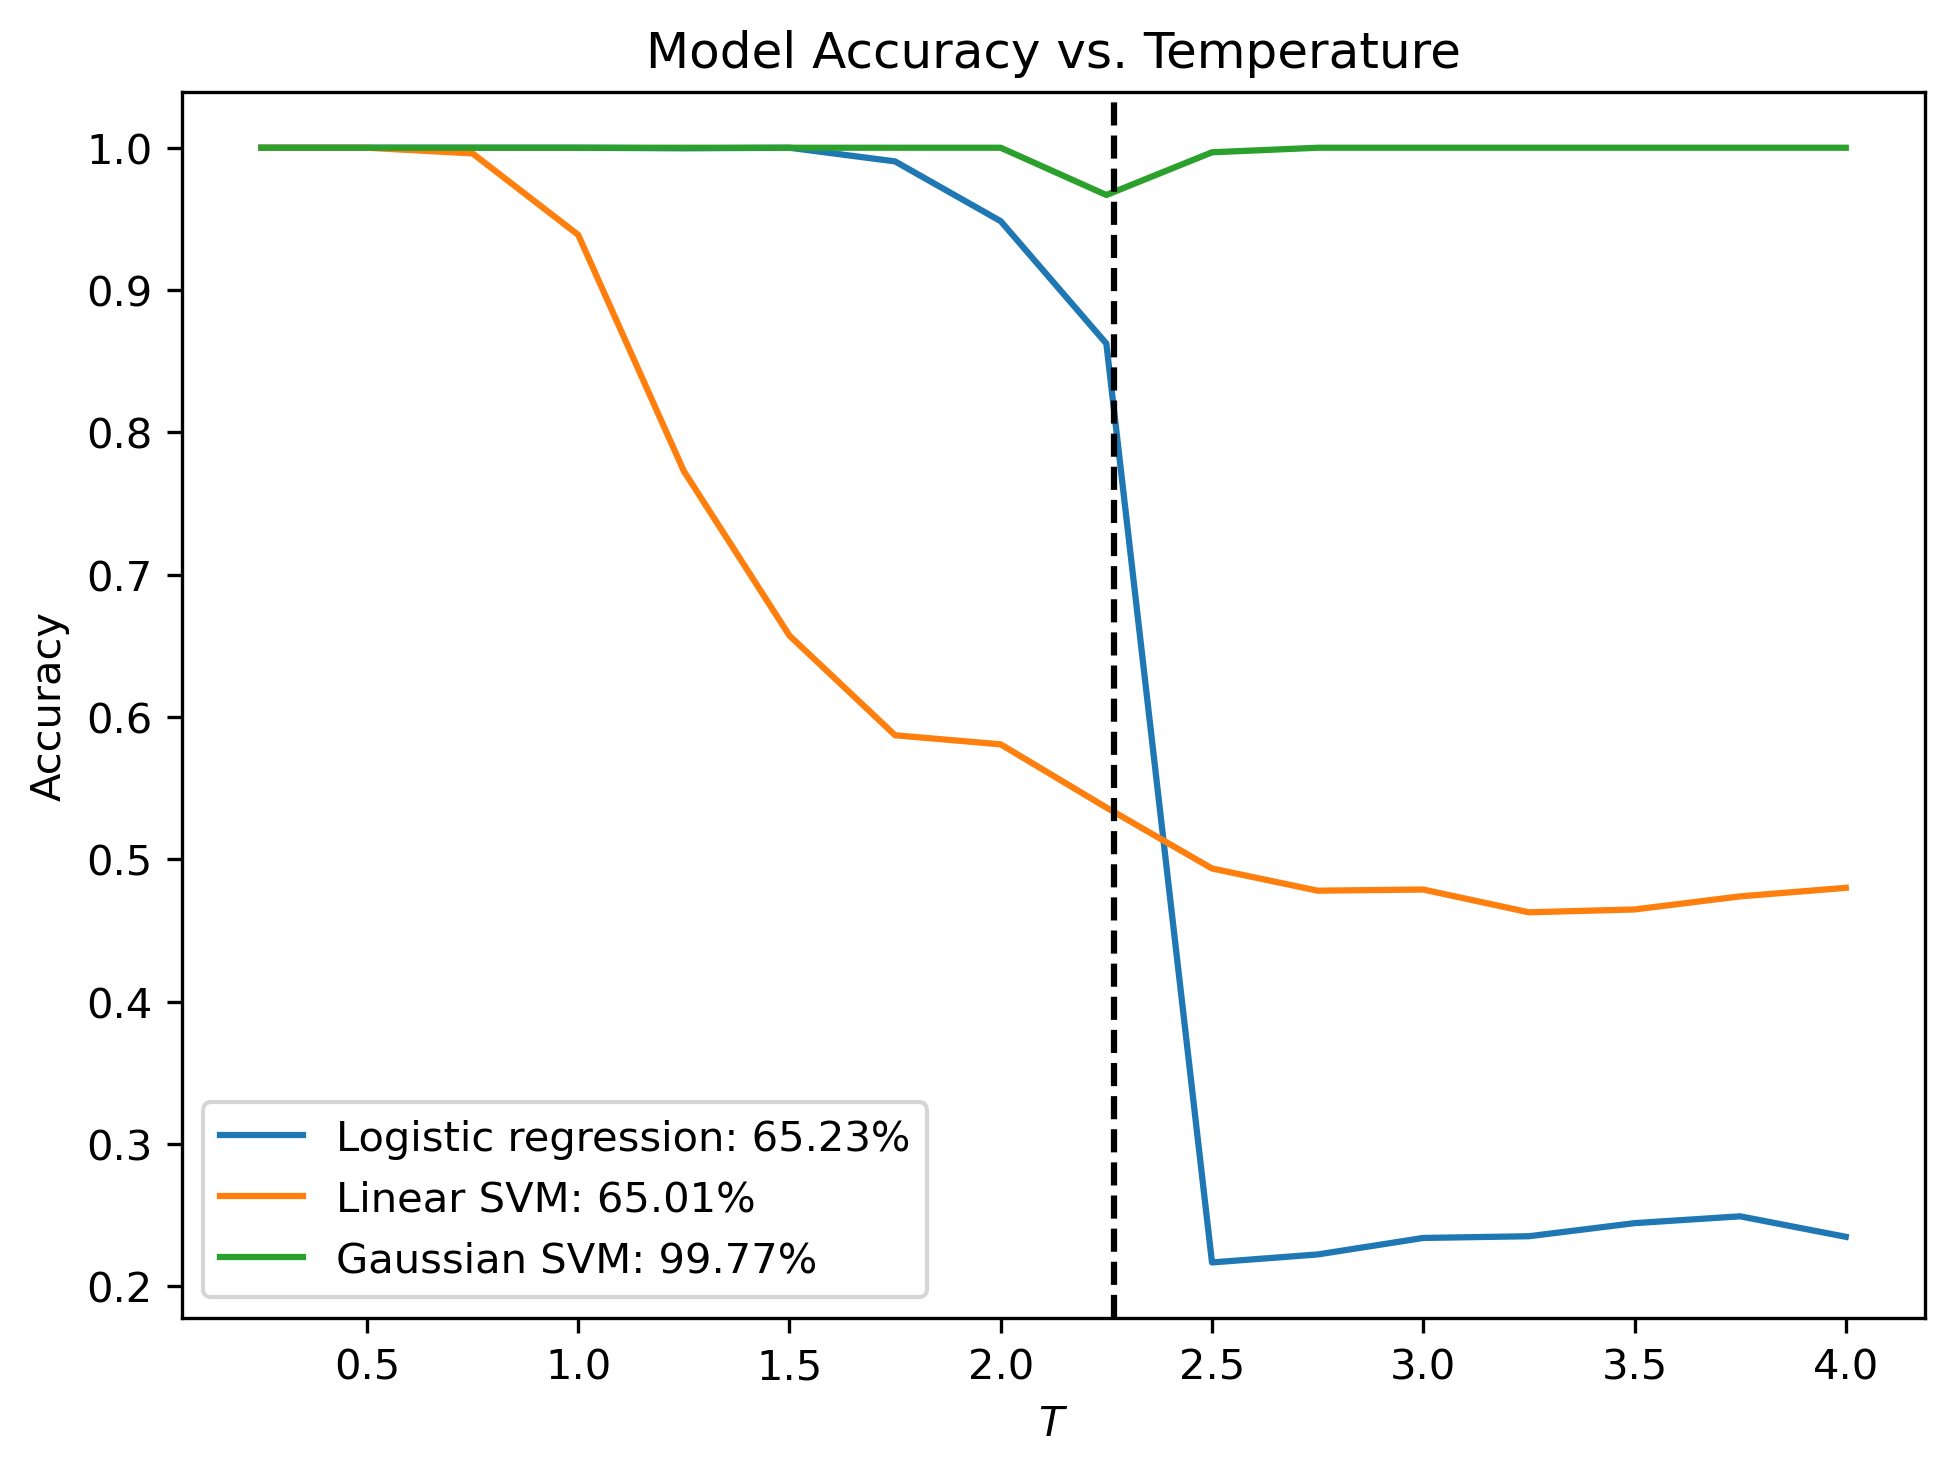

In [39]:
plt.figure(dpi = 300, layout = "constrained")
plt.plot(np.linspace(0.25, 4., 16), lr_scores_temps[0], label = "Logistic regression: {:.2%}".format(lr_scores[0]))
plt.plot(np.linspace(0.25, 4., 16), linear_svm_scores_temps[0], label = "Linear SVM: {:.2%}".format(linear_svm_scores[0]))
plt.plot(np.linspace(0.25, 4., 16), svm_scores_temps[0], label = "Gaussian SVM: {:.2%}".format(svm_scores[0]))
plt.axvline(T_c, color = "k", linestyle = "--")
plt.xlabel(r"$T$")
plt.ylabel("Accuracy")
plt.title("Model Accuracy vs. Temperature")
plt.legend()
plt.savefig("accuracy.pdf")